In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [16]:
data = r"G:\My Drive\New_Working_Files\KNIME\CTU_2026\ML_Models\Confusion_Matrix.csv"
df = pd.read_csv(data)
print(df.columns)

Index(['rts_breach', 'gmv', 'is_alpha_seller', 'is_fk_assured', 'is_large',
       'sla_in_days', 'listing_tier', 'analytic_category'],
      dtype='object')


In [17]:
print(df.dtypes)

rts_breach            object
gmv                    int64
is_alpha_seller         bool
is_fk_assured           bool
is_large             float64
sla_in_days          float64
listing_tier          object
analytic_category     object
dtype: object


In [19]:
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype =='object' or df[col].astype=='bool':
        df[col] = le.fit_transform(df[col].astype(str))

Classification Result
Model Accuracy: 0.91%

 --Detailed Buisness report
              precision    recall  f1-score   support

           0       1.00      0.00      0.00     45767
           1       0.91      1.00      0.95   1363127
           2       0.75      0.01      0.03     82191
           3       0.95      0.00      0.00      8915

    accuracy                           0.91   1500000
   macro avg       0.90      0.25      0.25   1500000
weighted avg       0.90      0.91      0.87   1500000

\ Top Drivers
sla_in_days          0.464644
gmv                  0.165012
analytic_category    0.163374
is_alpha_seller      0.134063
listing_tier         0.041026
is_fk_assured        0.031881
is_large             0.000000
dtype: float64


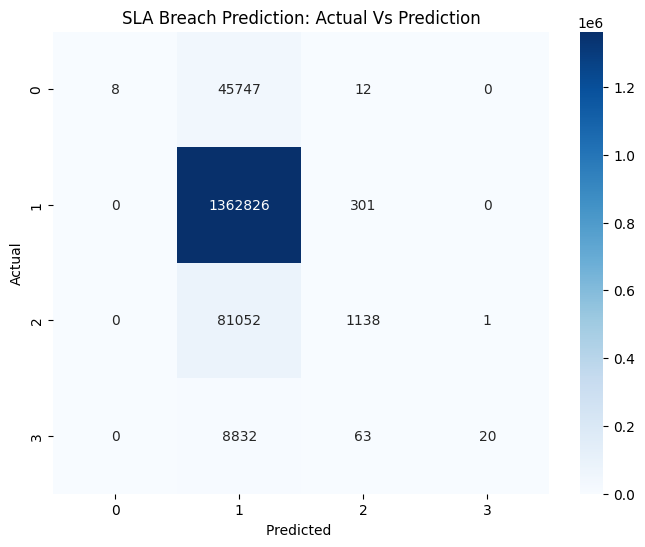

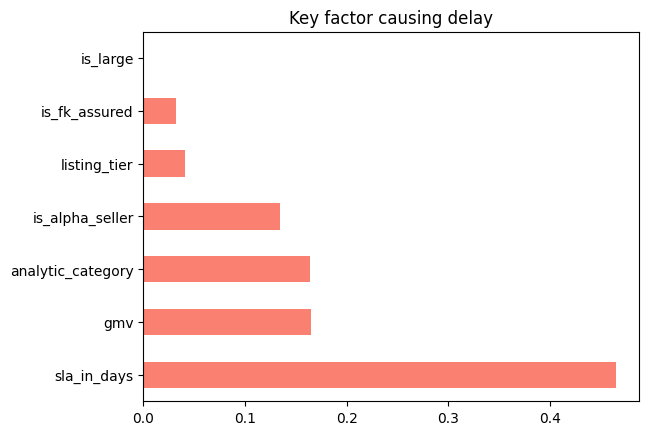

In [24]:
features = ['gmv', 'is_alpha_seller', 'is_fk_assured', 'is_large', 
            'sla_in_days', 'listing_tier', 'analytic_category']
X= df[features]
y= df['rts_breach']

model = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42)
model.fit(X,y)
y_pred = model.predict(X)
accuracy = accuracy_score(y, y_pred)

print(f"Classification Result")
print(f"Model Accuracy: {accuracy:.2f}%")

print("\n --Detailed Buisness report")
print(classification_report(y, y_pred))

importances = pd.Series(model.feature_importances_, index= features).sort_values(ascending=False)
print("\ Top Drivers")
print(importances)

plt.figure(figsize=(8,6))
cm = confusion_matrix(y, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("SLA Breach Prediction: Actual Vs Prediction")
plt.xlabel("Predicted ")
plt.ylabel("Actual")
plt.show()

importances.plot(kind='barh', color='salmon', title= "Key factor causing delay")
plt.show()